# Reproducing the iRoCS root-meristem analysis of Blein et al. (bioRxiv 353987)

**Paper:** *Light dynamically regulates growth rate and cellular organisation of the Arabidopsis root meristem* — T. Blein, J. Duerr, T. Pasternak, T. Haser, T. Falk, K. Liu, F. A. Ditengou, O. Ronneberger, K. Palme (2018), DOI [10.1101/353987](https://doi.org/10.1101/353987).
**Code:** [lmb-freiburg/iRoCS-Toolbox](https://github.com/lmb-freiburg/iRoCS-Toolbox) @ `50b8510331e6b3fed973a91adf340333447f9de1` (GPL-3.0).
**Data/models:** author sample `rootTip_short.h5` and author-trained SVM models from the [official iRoCS site](http://lmb.informatik.uni-freiburg.de/lmbsoft/iRoCS).

## What this notebook does (EN)

Runs the paper's own quantitative pipeline — the iRoCS Toolbox (Schmidt et al. 2014, cited throughout the paper) — end-to-end on the authors' sample DAPI root-tip stack: **nucleus detection (SVM) → epidermis labelling (SVM) → attach the intrinsic root coordinate system (iRoCS) → cell-layer assignment (SVM)**, then reproduces the paper's downstream **root-zonation analysis** (fit of the 6-parameter piecewise model of cell size vs. distance from the quiescent center, per the paper's Supplemental Method).

**Scope:** partial demonstration on one author-provided sample root (DAPI channel only). The cell-wall segmentation path (`segmentCells` → `computeCellFeatures` → `assignLayersToSegmentation`) is **not** exercisable because the sample is DAPI-only; the paper's cell-volume analysis used cell-wall-stained roots. This is not a re-computation of the paper's n=16/19 atlas.

## このノートブックがすること (JA)

論文の定量パイプライン（iRoCS Toolbox）を著者サンプルのDAPI根端画像で一気通貫で実行します: **核検出(SVM) → 表皮ラベリング(SVM) → 内在性根座標系(iRoCS)の付与 → 細胞層割り当て(SVM)**、続いて論文の**根ゾーン解析**（細胞サイズとQC距離の関係への6パラメータ区間モデルの補定、論文のSupplemental Methodに従う）を再現します。

**範囲:** 著者提供サンプル根1本（DAPIチャネルのみ）による部分実演。細胞壁セグメンテーション経路はこのサンプルでは実行不可（DAPIのみ）です。論文のn=16/19アトラス再計算ではありません。

## Execution status

**EXECUTED** — this notebook was run top-to-bottom on a Colab CPU runtime; the saved cell outputs are the actual results of that run. See the validation record at the end.

---

## Runtime selection and Run all instructions

- **Select a CPU runtime** (Runtime → Change runtime type → CPU). A GPU is **not** required or used: the iRoCS tools are CPU C++/OpenMP programs with no CUDA path. The whole notebook runs identically on any standard Colab CPU.
- **Run all** cells from top to bottom (Runtime → Run all). No manual steps, no credentials, no Drive mount.
- **Expected wall time:** ~20 min total — dependency install ~2 min, source build ~8–10 min, downloads ~1 min, pipeline ~8 min (nucleus detection dominates), analysis ~1 min. Downloads ≈ 140 MB. Free-tier CPU speed and availability may differ.

**Limitations.** (1) The paper indicated the quiescent center (QC) manually in the GUI; here the QC position is estimated from the detected nuclei (documented adaptation — it only sets the origin of the coordinate system). (2) The paper measured cell size as the interval between neighboring nuclei *in the same cell file*; cell-file assignment is a GUI-only operation in iRoCS v1.2.4, so we use the interval between consecutive nuclei within a (layer, angular-sector) group as an approximation. (3) The zone model is fitted with `scipy.optimize.least_squares` (the paper used MATLAB `fminunc`); same objective, 30 random restarts. (4) The GUI workflow is expressed through the authors' own command-line tools; GUI chrome (buttons, 3-D viewers) is intentionally omitted. (5) Automatic layer assignment is imperfect — the paper used expert-corrected annotations.

## 1. Runtime check

Confirms a CPU runtime and prints the environment. No GPU is needed.

CPUランタイムであることを確認し、環境を表示します。GPUは不要です。

In [ ]:
import os, platform, subprocess
print("Python:", platform.python_version())
print("Platform:", platform.platform())
try:
    nproc = os.cpu_count()
except Exception:
    nproc = "?"
print("CPU cores:", nproc)
r = subprocess.run(["free", "-h"], capture_output=True, text=True)
print(r.stdout.strip())
try:
    import h5py, numpy, scipy, matplotlib
    print("h5py", h5py.__version__, "| numpy", numpy.__version__,
          "| scipy", scipy.__version__, "| matplotlib", matplotlib.__version__)
except Exception as e:
    print("scientific stack import note:", e)

Python: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
CPU cores: 2
total        used        free      shared  buff/cache   available
Mem:            12Gi       888Mi       8.9Gi       2.1Mi       3.2Gi        11Gi
Swap:             0B          0B          0B
h5py 3.16.0 | numpy 2.1.3 | scipy 1.16.3 | matplotlib 3.10.0


## 2. Install build dependencies

Installs the system packages needed to build the iRoCS tools from the pinned source: blitz++, HDF5, FFTW3, GSL, OpenCV (core/imgproc), OpenGL/GLU, pkg-config. Qt4 is **not** installed — it is unavailable on current Ubuntu and is not needed by the four command-line tools (see the build patch below).

iRoCSツールをソースからビルドするためのシステムパッケージをインストールします。Qt4はインストールしません（現在のUbuntuで利用不可で、4つのCLIツールには不要です）。

In [ ]:
import subprocess, time
t0 = time.time()
r = subprocess.run("sudo apt-get update -qq && "
                   "sudo apt-get install -y -qq libblitz0-dev libfftw3-dev libgsl-dev "
                   "libopencv-dev libgl1-mesa-dev libglu1-mesa-dev pkg-config",
                   shell=True, capture_output=True, text=True, timeout=900)
print("apt rc:", r.returncode, f"{time.time()-t0:.0f}s")
print(r.stdout.strip()[-300:])
print(r.stderr.strip()[-300:] if r.stderr.strip() else "")

apt rc: 0 48s
alloc.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libumf.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm_debug.so.1 is not a symbolic link

Setting up libgtk-3-bin (3.24.41-4ubuntu1.3) ...
Setting up qt5-gtk-platformtheme:amd64 (5.15.13+dfsg-1ubuntu1) ...
share/perl5/Debconf/FrontEnd/Dialog.pm line 79, <STDIN> line 152.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin:


## 3. Download the pinned iRoCS source

Downloads the source tarball of the pinned commit `50b8510331e6b3fed973a91adf340333447f9de1` (iRoCS Toolbox v1.2.4, 2019-07-31) from GitHub. This is the exact revision the paper's pipeline corresponds to.

Pin留めされたコミット `50b8510...` のソースをGitHubからダウンロードします。

In [ ]:
import subprocess, os, time
WORK = "/content/irocs"
os.makedirs(WORK, exist_ok=True)
url = "https://github.com/lmb-freiburg/iRoCS-Toolbox/archive/50b8510331e6b3fed973a91adf340333447f9de1.tar.gz"
tar = f"{WORK}/irocs_src.tar.gz"
if not os.path.exists(tar):
    r = subprocess.run(["curl", "-sL", "--fail-with-body", "--max-time", "300", url, "-o", tar],
                       capture_output=True, text=True, timeout=360)
    print("download rc:", r.returncode)
print("source bytes:", os.path.getsize(tar))
subprocess.run(["tar", "xzf", tar, "-C", WORK], check=True)
SRC = f"{WORK}/iRoCS-Toolbox-50b8510331e6b3fed973a91adf340333447f9de1"
print("source dir:", SRC, os.path.isdir(SRC))

download rc: 0
source bytes: 2173979
source dir: /content/irocs/iRoCS-Toolbox-50b8510331e6b3fed973a91adf340333447f9de1 True


## 4. Apply behavior-preserving build patches

The pinned source targets an older toolchain. Four minimal, behavior-preserving patches are applied so it builds on a current Colab (Ubuntu 24.04) system. None of them touch the scientific computation:

1. **Top-level `CMakeLists.txt`** — remove the unconditional `find_package(Qt4 ... REQUIRED)` and `find_package(OpenGL REQUIRED)`, and guard the Qt export targets. The four CLI tools do not use Qt or OpenGL; the Qt-only subdirectories are skipped by configuring with `-DBUILD_SHARED_LIBS=OFF`.
2. **`src/libBaseFunctions/BaseFile.cc`** — drop the unused `#include <sys/sysctl.h>` (removed from modern glibc; `sysctl()` is never called).
3. **OpenCV 2.x/3.x → 4.x** — update header paths (`opencv/cxcore.h`, `opencv2/core/core.hpp`, `opencv2/imgproc/imgproc.hpp`) and the `CvRNG`/`cvRandReal`/`cvRandInt` C API to `cv::RNG`. This affects only the cell-segmentation random-forest code, which is **not** on the nuclei path used here.
4. **`src/libsvmtl/SvmH5Type.hh`** — HDF5 1.10 removed the implicit `H5::DataType` → `hid_t`/`bool` conversion in the `NO_TYPE` fallback; return explicit values.

古いツールチェーンを前提とするソースを現在のColabでビルドするための、挙動を変えない最小パッチを4つ適用します。科学計算には影響しません。

In [ ]:
import os
SRC = "/content/irocs/iRoCS-Toolbox-50b8510331e6b3fed973a91adf340333447f9de1"

def patch(path, pairs):
    t = open(path).read()
    for a, b in pairs:
        t = t.replace(a, b)
    open(path, "w").write(t)

# 1. CMakeLists: drop Qt4/OpenGL, guard Qt export targets
patch(f"{SRC}/CMakeLists.txt", [
    ("find_package(Qt4 4.6 REQUIRED COMPONENTS QtCore QtGui QtOpenGL QtXml QtSvg )\n", ""),
    ("find_package(OpenGL REQUIRED)\n", ""),
    ("      segmentation_static IRoCS_static ProgressReporter_qt4_static\n      Labelling_qt4_static\n",
     "      segmentation_static IRoCS_static\n"),
    ("      if (Qt5Widgets_FOUND)\n        export(TARGETS ProgressReporter_qt5_static\n\tAPPEND FILE \"${PROJECT_BINARY_DIR}/iRoCS-ToolboxTargets.cmake\"\n\tNAMESPACE iRoCS-Toolbox::)\n      endif()\n", ""),
])
# 2. BaseFile.cc: drop unused sys/sysctl.h
patch(f"{SRC}/src/libBaseFunctions/BaseFile.cc", [
    ("#include <sys/sysctl.h>\n", ""),
])
# 3. OpenCV 2.x/3.x -> 4.x
algo = f"{SRC}/src/libArrayToolbox/algo"
patch(f"{algo}/lRandomTree.hh", [
    ("#include <opencv/cxcore.h>", "#include <opencv2/core.hpp>"),
    ("CvRNG *_cvRNG;", "cv::RNG *_cvRNG;"),
    ("CvRNG *pRNG", "cv::RNG *pRNG"),
])
patch(f"{algo}/lRandomTree.cc", [
    ("CvRNG *pRNG", "cv::RNG *pRNG"),
    ("cvRandReal(_cvRNG)", "_cvRNG->uniform(0.0f, 1.0f)"),
    ("cvRandInt(_cvRNG)", "_cvRNG->uniform(0, 2147483647)"),
])
patch(f"{algo}/lRandomForest.cc", [
    ("CvRNG cvRNG(i + 1);", "cv::RNG cvRNG(i + 1);"),
    ("CvRNG cvRNG(200);", "cv::RNG cvRNG(200);"),
    ("cvRandInt(&cvRNG)", "cvRNG.uniform(0, 2147483647)"),
    ("cvRandReal(&cvRNG)", "cvRNG.uniform(0.0f, 1.0f)"),
])
for hh in ["ShellCoordinateTransform.hh", "RootCoordinateTransform.hh"]:
    patch(f"{algo}/{hh}", [
        ("opencv2/core/core.hpp", "opencv2/core.hpp"),
        ("opencv2/imgproc/imgproc.hpp", "opencv2/imgproc.hpp"),
    ])
# 4. SvmH5Type.hh: H5::DataType -> hid_t/bool conversion removed in HDF5 1.10
patch(f"{SRC}/src/libsvmtl/SvmH5Type.hh", [
    ('''  static hid_t h5DataTypeId()
        {
          SVMError err;
          err << "BlitzH5Type::NO_TYPE: Data type not supported.";
          //throw(err);
          return H5::DataType();
        }''', '''  static hid_t h5DataTypeId()
        {
          SVMError err;
          err << "BlitzH5Type::NO_TYPE: Data type not supported.";
          //throw(err);
          return (hid_t)-1;
        }'''),
    ('''  static bool isVectorial()
        {
          SVMError err;
          err << "BlitzH5Type::NO_TYPE: Data type not supported.";
          //throw(err);
          return H5::DataType();
        }''', '''  static bool isVectorial()
        {
          SVMError err;
          err << "BlitzH5Type::NO_TYPE: Data type not supported.";
          //throw(err);
          return false;
        }'''),
])
print("all patches applied")

all patches applied


## 5. Build the four command-line tools

Configures a static-library build (no Qt, no tests) and compiles `detectNuclei`, `labelEpidermis`, `attachIRoCS`, and `assignLayers`. Only these four tools are built; the GUI and plugins are not.

静的ライブラリ構成（Qtなし、テストなし）で4つのCLIツールをビルドします。

In [ ]:
import subprocess, os, time
SRC = "/content/irocs/iRoCS-Toolbox-50b8510331e6b3fed973a91adf340333447f9de1"
BUILD = f"{SRC}/build"
os.makedirs(BUILD, exist_ok=True)
t0 = time.time()
r = subprocess.run(["cmake", "..", "-DCMAKE_BUILD_TYPE=Release",
                    "-DBUILD_SHARED_LIBS=OFF", "-DBUILD_STATIC_LIBS=ON",
                    "-DBUILD_TESTS=OFF", "-DBUILD_STATIC_TOOLS=OFF"],
                   capture_output=True, text=True, timeout=600, cwd=BUILD)
print("cmake rc:", r.returncode, f"{time.time()-t0:.0f}s")
print(r.stderr.strip()[-200:] if r.stderr.strip() else "")
if r.returncode != 0:
    print(r.stdout[-1500:])
    raise SystemExit("cmake configure failed")
t0 = time.time()
r = subprocess.run("make -j$(nproc) detectNuclei labelEpidermis attachIRoCS assignLayers",
                   shell=True, capture_output=True, text=True, timeout=2400, cwd=BUILD)
print("make rc:", r.returncode, f"{time.time()-t0:.0f}s")
print(r.stdout.strip()[-400:])
if r.returncode != 0:
    print(r.stderr[-2000:])
    raise SystemExit("build failed")
TOOLS = {
    "detectNuclei": f"{BUILD}/src/tools/detectNuclei/detectNuclei",
    "labelEpidermis": f"{BUILD}/src/tools/labelEpidermis/labelEpidermis",
    "attachIRoCS": f"{BUILD}/src/tools/attachIRoCS/attachIRoCS",
    "assignLayers": f"{BUILD}/src/tools/assignLayers/assignLayers",
}
for k, v in TOOLS.items():
    print(k, "->", v, os.path.exists(v))

cmake rc: 0 4s
he VERSION argument <min> value.  Or, use the <min>...<max> syntax
  to tell CMake that the project requires at least <min> but has been updated
  to work with policies introduced by <max> or earlier.


make rc: 0 515s
tatic
[ 30%] Built target lmbs2kit_static
[ 33%] Built target BlitzFFTW_static
[ 36%] Built target BlitzHdf5_static
[ 67%] Built target ArrayToolbox_static
[ 81%] Built target segmentation_static
[ 98%] Built target IRoCS_static
[100%] Building CXX object src/tools/assignLayers/CMakeFiles/assignLayers.dir/assignLayers.cc.o
[100%] Linking CXX executable assignLayers
[100%] Built target assignLayers
detectNuclei -> /content/irocs/iRoCS-Toolbox-50b8510331e6b3fed973a91adf340333447f9de1/build/src/tools/detectNuclei/detectNuclei True
labelEpidermis -> /content/irocs/iRoCS-Toolbox-50b8510331e6b3fed973a91adf340333447f9de1/build/src/tools/labelEpidermis/labelEpidermis True
attachIRoCS -> /content/irocs/iRoCS-Toolbox-50b8510331e6b3fed973a91adf340333447f9de1/build/src/tools/attachIRoCS/attachIRoCS True
assignLayers -> /content/irocs/iRoCS-Toolbox-50b8510331e6b3fed973a91adf340333447f9de1/build/src/tools/assignLayers/assignLayers True


## 6. Download the author models and sample data

Downloads the three author-trained SVM models and the author sample DAPI stack from the official iRoCS site. All bytes stay on this Colab VM. The sample is `rootTip_short.h5`: a DAPI-stained Arabidopsis root tip, `/t0/channel0`, 8-bit, 70×1024×1024 voxels, covering ~150 μm from the QC (element size 1.099 × 0.143 × 0.143 μm).

著者学習済みSVMモデル3点と著者サンプルDAPI画像を公式サイトからダウンロードします。

In [ ]:
import subprocess, os, time
PROBE = "/content/data"
os.makedirs(PROBE, exist_ok=True)
BASE = "https://lmb.informatik.uni-freiburg.de/lmbsoft/iRoCS"
files = {
    "nucleusDetector_svmModel.h5": f"{BASE}/nucleusDetector_svmModel.h5",
    "epidermisLabelling_svmModel.h5": f"{BASE}/epidermisLabelling_svmModel.h5",
    "layerAssignment_svmModel.h5": f"{BASE}/layerAssignment_svmModel.h5",
    "rootTip_short.h5": f"{BASE}/rootTip_short.h5",
}
for name, url in files.items():
    dest = f"{PROBE}/{name}"
    if os.path.exists(dest):
        print(f"exists: {name} ({os.path.getsize(dest)} bytes)")
        continue
    t0 = time.time()
    r = subprocess.run(["curl", "-sL", "--fail-with-body", "--max-time", "600", url, "-o", dest],
                       capture_output=True, text=True, timeout=660)
    ok = r.returncode == 0 and os.path.exists(dest) and os.path.getsize(dest) > 0
    print(f"{'OK' if ok else 'FAIL'}: {name} {os.path.getsize(dest) if os.path.exists(dest) else 0} bytes {time.time()-t0:.0f}s")
    if not ok:
        raise RuntimeError(f"download failed: {url}")

OK: nucleusDetector_svmModel.h5 1771352 bytes 2s


OK: epidermisLabelling_svmModel.h5 15666648 bytes 3s


OK: layerAssignment_svmModel.h5 12194376 bytes 3s


OK: rootTip_short.h5 73520832 bytes 13s


## 7. Input preview and preprocessing

Inspects the sample HDF5 structure and renders a maximum-intensity projection of the DAPI stack. The iRoCS tools require a `transformation` attribute on the dataset; the source build falls back to identity when it is absent, so we add it explicitly (identity ⇒ position_um = voxel_index × element_size_um).

サンプルHDF5の構造を確認し、DAPI画像の最大強度投影を表示します。iRoCSツールはデータセットに`transformation`属性を必要とするため、明示的に追加します（恒等変換 ⇒ position_um = 体素インデックス × element_size_um）。

GR t0


DS t0/channel0 shape=(70, 1024, 1024) dtype=uint8
  attr /t0/channel0@element_size_um = [1.099   0.14282 0.14282]
  attr /t0/channel0@selection_extents = [  70 1024 1024]
voxel size (Z Y X): [1.099   0.14282 0.14282]


saved preview_dapi.png


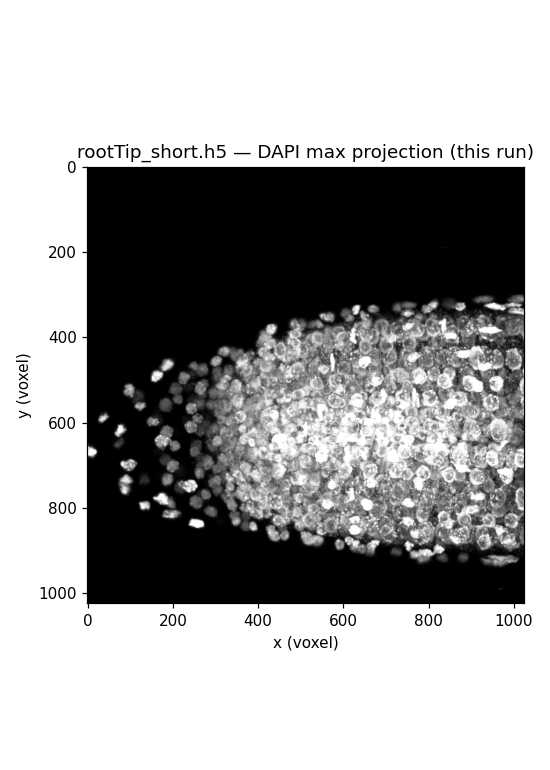

In [ ]:
import h5py, numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

SAMPLE = "/content/data/rootTip_short.h5"
with h5py.File(SAMPLE, "r") as f:
    def show(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"DS {name} shape={obj.shape} dtype={obj.dtype}")
        else:
            print(f"GR {name}")
    f.visititems(show)
    for k, v in f["/t0/channel0"].attrs.items():
        print(f"  attr /t0/channel0@{k} = {v}")
    img = f["/t0/channel0"][:]
    voxel = f["/t0/channel0"].attrs["element_size_um"]
print("voxel size (Z Y X):", voxel)

fig, ax = plt.subplots(figsize=(5, 7))
ax.imshow(img.max(axis=0), cmap="gray")
ax.set_title("rootTip_short.h5 — DAPI max projection (this run)")
ax.set_xlabel("x (voxel)"); ax.set_ylabel("y (voxel)")
plt.tight_layout()
plt.savefig("/content/data/preview_dapi.png", dpi=110)
plt.close()
print("saved preview_dapi.png")

from IPython.display import display, Image
display(Image("/content/data/preview_dapi.png"))

## 8. Nucleus detection (SVM)

Runs `detectNuclei` with the author's `nucleusDetector_svmModel.h5`. The detector classifies every voxel with a multi-scale feature vector (σ = 0.5…64, band-max 5, plus 4 Hough features) and extracts local maxima as nucleus candidates. This is the longest step (~8 min on a standard Colab CPU). Results are written to the `/annotation/detector` group of a working copy of the sample.

著者の`nucleusDetector_svmModel.h5`で`detectNuclei`を実行します。全ボクセルをマルチスケール特徴量で分類し、局所最大値を核候補として抽出します。最も時間がかかるステップです（標準Colab CPUで約8分）。

In [ ]:
import subprocess, os, time
import h5py, numpy as np

TOOLS = {
    "detectNuclei": "/content/irocs/iRoCS-Toolbox-50b8510331e6b3fed973a91adf340333447f9de1/build/src/tools/detectNuclei/detectNuclei",
    "labelEpidermis": "/content/irocs/iRoCS-Toolbox-50b8510331e6b3fed973a91adf340333447f9de1/build/src/tools/labelEpidermis/labelEpidermis",
    "attachIRoCS": "/content/irocs/iRoCS-Toolbox-50b8510331e6b3fed973a91adf340333447f9de1/build/src/tools/attachIRoCS/attachIRoCS",
    "assignLayers": "/content/irocs/iRoCS-Toolbox-50b8510331e6b3fed973a91adf340333447f9de1/build/src/tools/assignLayers/assignLayers",
}
PROBE = "/content/data"
workfile = f"{PROBE}/rootTip_annotated.h5"
subprocess.run(["cp", f"{PROBE}/rootTip_short.h5", workfile], check=True)

# add identity transformation attribute (source build warns if absent)
with h5py.File(workfile, "a") as f:
    ds = f["/t0/channel0"]
    if "transformation" not in ds.attrs:
        ds.attrs["transformation"] = np.eye(4, dtype=np.float64)
        print("added identity transformation attribute")

def run(tool, args, timeout=2400):
    t0 = time.time()
    r = subprocess.run([TOOLS[tool]] + args, capture_output=True, text=True, timeout=timeout)
    dt = time.time() - t0
    tail = (r.stdout or "").strip().splitlines()[-2:]
    print(f"[{tool}] rc={r.returncode} {dt:.1f}s")
    for line in tail:
        print("   ", line)
    if r.returncode != 0:
        print("STDERR:", r.stderr[-800:])
        raise RuntimeError(f"{tool} failed")
    return r

run("detectNuclei", ["-d", "/t0/channel0", "-m", f"{PROBE}/nucleusDetector_svmModel.h5",
                     "-c", f"{PROBE}/features.h5", "-n", "/annotation/detector", workfile])

added identity transformation attribute


[detectNuclei] rc=0 627.5s
      1757 nucleus candidates remaining
    Saving '/content/data/rootTip_annotated.h5:/annotation/detector'


CompletedProcess(args=['/content/irocs/iRoCS-Toolbox-50b8510331e6b3fed973a91adf340333447f9de1/build/src/tools/detectNuclei/detectNuclei', '-d', '/t0/channel0', '-m', '/content/data/nucleusDetector_svmModel.h5', '-c', '/content/data/features.h5', '-n', '/annotation/detector', '/content/data/rootTip_annotated.h5'], returncode=0, stdout="Loading '/content/data/rootTip_annotated.h5:/t0/channel0'\nInitializing iRoCS::Features... OK\nLoading normalization parameters from '/content/data/nucleusDetector_svmModel.h5'\nComputing chunk size\nClassifying in 1 chunk with chunksize 1620016 (1235 MB)\nInitializing test vectors\nCache miss for feature '/features/SDmag/sigma00.5_laplace0000_l0000'. Updating cache...\nProcessing '/content/data/features.h5:/t0/scale_1.0/channel0'\nScaling dataset\nNormalizing dataset\nSaving '/content/data/features.h5:/t0/scale_1.0/channel0'\nProcessing '/content/data/features.h5:/features/SDmag/sigma00.5_laplace0000_l0000'\nSmoothing...\nSaving '/content/data/features.h

## 9. Epidermis labelling (SVM)

Runs `labelEpidermis` with the author's `epidermisLabelling_svmModel.h5`, classifying each detected nucleus as epidermis (label 2), other (−1), or background (0). Uses the feature cache written by the detection step.

著者の`epidermisLabelling_svmModel.h5`で`labelEpidermis`を実行します。

In [ ]:
run("labelEpidermis", ["-d", "/t0/channel0", "-m", f"{PROBE}/epidermisLabelling_svmModel.h5",
                       "-c", f"{PROBE}/features.h5", "-n", "/annotation/detector", workfile])

[labelEpidermis] rc=0 10.7s
      96% doneClassification finished
    Saving '/content/data/rootTip_annotated.h5:/annotation/detector'


CompletedProcess(args=['/content/irocs/iRoCS-Toolbox-50b8510331e6b3fed973a91adf340333447f9de1/build/src/tools/labelEpidermis/labelEpidermis', '-d', '/t0/channel0', '-m', '/content/data/epidermisLabelling_svmModel.h5', '-c', '/content/data/features.h5', '-n', '/annotation/detector', '/content/data/rootTip_annotated.h5'], returncode=0, stdout="Loading '/content/data/rootTip_annotated.h5:/t0/channel0'\nLoading '/content/data/rootTip_annotated.h5:/annotation/detector'\nInitializing iRoCS::Features... OK\nLoading normalization parameters from /content/data/epidermisLabelling_svmModel.h5\n\n  1% done\n  2% done\n  3% donePreparing feature vectors\n\n  4% doneCache miss for feature '/features/SDmag/sigma00.5_laplace0000_l0000'. Updating cache...\nProcessing '/content/data/features.h5:/t0/scale_1.0/channel0'\nProcessing '/content/data/features.h5:/features/SDmag/sigma00.5_laplace0000_l0000'\n\n  3% doneCache miss for feature '/features/SDmag/sigma00.5_laplace0000_l0001'. Updating cache...\nPro

## 10. Attach the intrinsic root coordinate system (iRoCS)

The paper indicates the quiescent center (QC) manually in the GUI. Here we estimate it from the detected nuclei: the root-tip end is the z-extent end with the lower nucleus density in the outer 20 μm, and the QC is the centroid of nuclei within 10 μm of that end. This estimated position is written as an `/annotation/qc` marker group (the format `attachIRoCS` reads) and used as the origin of the iRoCS coordinate system. `attachIRoCS` then fits the root axis and computes each nucleus's QC distance, radial distance, and φ.

論文ではQCをGUIで手動指示します。ここでは検出核からQC位置を推定し、`/annotation/qc`マーカーグループとして書き込み、iRoCS座標系の原点として使用します。

In [ ]:
import numpy as np
with h5py.File(workfile, "r") as f:
    pos = f["/annotation/detector/position_um"][:]
z = pos[:, 0]
zlo, zhi = z.min(), z.max()
d_lo = ((z < zlo + 20).sum()) / 20.0
d_hi = ((z > zhi - 20).sum()) / 20.0
tip_end = zlo if d_lo < d_hi else zhi
qc = pos[np.abs(z - tip_end) < 10].mean(axis=0)
print(f"detected nuclei: {len(pos)}; z range {zlo:.1f}..{zhi:.1f} um")
print(f"tip end z={tip_end:.1f} um; estimated QC (Z Y X) = {np.round(qc, 2)}")

with h5py.File(workfile, "a") as f:
    g = f.require_group("/annotation/qc")
    if "position_um" in g:
        del g["position_um"]
    g.create_dataset("position_um", data=qc.reshape(1, 3))

run("attachIRoCS", ["-n", "/annotation/detector", "-q", "/annotation/qc",
                    "-a", "/annotation/axis", workfile])

detected nuclei: 1757; z range 1.0..74.0 um
tip end z=1.0 um; estimated QC (Z Y X) = [  6.85  88.51 116.78]


[attachIRoCS] rc=0 0.4s
    Saving '/content/data/rootTip_annotated.h5:/annotation/axis'
    Saving '/content/data/rootTip_annotated.h5:/annotation/detector'


CompletedProcess(args=['/content/irocs/iRoCS-Toolbox-50b8510331e6b3fed973a91adf340333447f9de1/build/src/tools/attachIRoCS/attachIRoCS', '-n', '/annotation/detector', '-q', '/annotation/qc', '-a', '/annotation/axis', '/content/data/rootTip_annotated.h5'], returncode=0, stdout="Loading '/content/data/rootTip_annotated.h5:/annotation/detector'\nLoading '/content/data/rootTip_annotated.h5:/annotation/qc'\n\n  0.909091% doneAttaching iRoCS...\nExtracting Epidermis nuclei\nComputing euclidean normalization transformation\n  Translation (um): (42.9128,88.5596,104.399)\n  Rotation        : (-0.301713,-0.130394,-0.94444; -0.313306,0.949148,-0.030954; 0.900449,0.28656,-0.327224)\n  Scale           : (23.65,21.925,18.2909)\n  Transformation  : (0.301713,0.130394,-0.94444,42.9128; 0.313306,-0.949148,-0.030954,88.5596; -0.900449,-0.28656,-0.327224,104.399; 0,0,0,1)\nTransforming nuclei\n  Nucleus range along main axis is: -50.5612 - 51.304 um\n  Normalized QC position is (-22.0451,-8.20219,30.0045)

## 11. Cell-layer assignment (SVM)

Runs `assignLayers` with the author's `layerAssignment_svmModel.h5`, assigning each nucleus to a root layer: 1 root cap, 2 epidermis, 3 cortex, 4 endodermis, 5 pericycle, 6 vasculature (0 = background/unclassified).

著者の`layerAssignment_svmModel.h5`で`assignLayers`を実行し、各核を根の層に割り当てます。

In [ ]:
run("assignLayers", ["-d", "/t0/channel0", "-m", f"{PROBE}/layerAssignment_svmModel.h5",
                     "-c", f"{PROBE}/features.h5", "-a", "/annotation/axis",
                     "-n", "/annotation/detector", workfile])

[assignLayers] rc=0 7.4s
      97% doneClassification finished
    Saving '/content/data/rootTip_annotated.h5:/annotation/detector'


CompletedProcess(args=['/content/irocs/iRoCS-Toolbox-50b8510331e6b3fed973a91adf340333447f9de1/build/src/tools/assignLayers/assignLayers', '-d', '/t0/channel0', '-m', '/content/data/layerAssignment_svmModel.h5', '-c', '/content/data/features.h5', '-a', '/annotation/axis', '-n', '/annotation/detector', '/content/data/rootTip_annotated.h5'], returncode=0, stdout="Loading '/content/data/rootTip_annotated.h5:/t0/channel0'\nLoading '/content/data/rootTip_annotated.h5:/annotation/detector'\nLoading '/content/data/rootTip_annotated.h5:/annotation/axis'\nStarting layer assignment\nInitializing iRoCS::Features... OK\nLoading normalization parameters from /content/data/layerAssignment_svmModel.h5\n\n  1% done\n  2% done\n  3% done\n  12% doneNormalizing features\nNormalizing '/features/SDmag/' to unit norm\nNormalizing individual features of '/features/SDmag/' to zero mean and unit standard deviation\nNormalizing individual features of '/features/hough/' to zero mean and unit standard deviation\n

## 12. Read back the annotated result

Reads the final per-nucleus table (position, layer, QC distance, φ, radial distance, radius) and prints the layer distribution — the raw material for the paper's per-layer cell-atlas analysis.

最終的な核ごとのテーブルを読み戻し、層分布を表示します。

In [ ]:
import h5py, numpy as np
import pandas as pd

with h5py.File(workfile, "r") as f:
    pos = f["/annotation/detector/position_um"][:]
    label = f["/annotation/detector/label"][:]
    qcd = f["/annotation/detector/qcDistance_um"][:]
    phi = f["/annotation/detector/phi"][:]
    rad = f["/annotation/detector/radialDistance_um"][:]
    radius = f["/annotation/detector/radius_um"][:]

names = {1: "root cap", 2: "epidermis", 3: "cortex", 4: "endodermis", 5: "pericycle", 6: "vasculature"}
print(f"nuclei: {len(pos)}")
for lab in sorted(set(label.tolist())):
    print(f"  layer {lab} ({names.get(lab, '?')}): {(label == lab).sum()}")
print(f"QC distance: {qcd.min():.1f} .. {qcd.max():.1f} um")
print(f"phi: {phi.min():.2f} .. {phi.max():.2f} rad")
print(f"nucleus radius: median {np.median(radius):.2f} um")

df = pd.DataFrame({"Z_um": pos[:, 0], "Y_um": pos[:, 1], "X_um": pos[:, 2],
                   "layer": label, "layer_name": [names.get(l, "background") for l in label],
                   "qcDistance_um": qcd, "phi_rad": phi,
                   "radialDistance_um": rad, "radius_um": radius})
df.to_csv("/content/data/nuclei_atlas.csv", index=False)
print("saved nuclei_atlas.csv")

nuclei: 1757
  layer 0 (?): 509
  layer 1 (root cap): 471
  layer 2 (epidermis): 243
  layer 3 (cortex): 93
  layer 4 (endodermis): 148
  layer 5 (pericycle): 123
  layer 6 (vasculature): 170
QC distance: -27.9 .. 120.8 um
phi: -3.14 .. 3.14 rad
nucleus radius: median 2.00 um
saved nuclei_atlas.csv


## 13. Cell-size proxy

For nuclei-stained data the paper uses "the interval between neighboring nuclei in the same cell file" as an approximate cell size (Supplemental Method). Cell-file assignment is a GUI-only operation in iRoCS v1.2.4, so we approximate it: within each (layer, angular-sector of φ) group, sort nuclei by QC distance and take the consecutive interval. This is a documented adaptation.

核染色データでは、論文は「同一細胞列内の隣接核の間隔」を細胞サイズの近似として使用します。細胞列割り当てはv1.2.4ではGUIのみの操作なので、(層, φの角セクトル)グループ内でQC距離順にソートし、隣接間隔を取ることで近似します。

In [ ]:
import numpy as np

def cell_size_proxy(mask, nphi=12):
    x = qcd[mask]
    ph = phi[mask]
    sector = np.floor((ph + np.pi) / (2 * np.pi) * nphi).astype(int) % nphi
    xs_all, y_all = [], []
    for s in range(nphi):
        m = sector == s
        xs = x[m]
        if len(xs) < 2:
            continue
        order = np.argsort(xs)
        xs = xs[order]
        y = np.diff(xs)
        xm = 0.5 * (xs[:-1] + xs[1:])
        xs_all.append(xm)
        y_all.append(y)
    return np.concatenate(xs_all), np.concatenate(y_all)

for lab in [3, 2]:
    xm, y = cell_size_proxy(label == lab)
    keep = y > 0.5
    print(f"layer {lab} ({names[lab]}): {keep.sum()} intervals, "
          f"median {np.median(y[keep]):.2f} um, range {y[keep].min():.2f}..{y[keep].max():.2f} um")

layer 3 (cortex): 79 intervals, median 6.57 um, range 0.68..47.54 um
layer 2 (epidermis): 209 intervals, median 3.79 um, range 0.52..30.86 um


## 14. Root-zonation model (Supplemental Method)

Fits the paper's 6-parameter piecewise model f(x; θ), θ = (x1, x2, y1, y2, y3, y4), to the binned cell-size proxy vs. QC distance. The model is a constant part (MZ), a linearly increasing part (EZ), and a constant part (DZ), joined by sigmoid transitions, with a = (y3−y2)/(x2−x1), b1 = y2−y1, b2 = y4−y3. Following the supplement, 30 random restarts are run and the fit with the lowest error is kept. We use a monotonic re-parameterization (y2 = y1+d1, y3 = y2+d2, y4 = y3+d3, dᵢ ≥ 0) so cell size increases from MZ to DZ, as in a real root. The fit is done with `scipy.optimize.least_squares` (the paper used MATLAB `fminunc`).

論文の6パラメータ区間モデルを、ビン化した細胞サイズプロキシ vs QC距離に補定します。30回のランダムリスタートで最良解を選びます（論文のSupplemental Methodに従う）。単調再パラメータ化を使用します。

In [ ]:
from scipy.optimize import least_squares

def zone_model(x, p):
    x1, x2, y1, y2, y3, y4 = p
    a = (y3 - y2) / (x2 - x1)
    b1 = y2 - y1
    b2 = y4 - y3
    y = np.empty_like(x)
    m1 = x < x1
    m2 = (x >= x1) & (x <= x2)
    m3 = x > x2
    with np.errstate(over="ignore", invalid="ignore"):
        y[m1] = y1 + (y2 - y1) / (1.0 + np.exp(2 * a * (x1 - x[m1]) / b1))
        y[m2] = y2 + a * (x[m2] - x1)
        y[m3] = y3 + (y4 - y3) / (1.0 + np.exp(2 * a * (x2 - x[m3]) / b2))
    return y

def zone_model_mono(x, q):
    x1, x2, y1, d1, d2, d3 = q
    return zone_model(x, [x1, x2, y1, y1 + d1, y1 + d1 + d2, y1 + d1 + d2 + d3])

def fit_zone(x, y, nrestart=30, seed=0):
    rng = np.random.default_rng(seed)
    xlo, xhi = x.min(), x.max()
    ylo, yhi = np.percentile(y, [2, 98])
    best = None
    for _ in range(nrestart):
        q0 = np.array([
            xlo + 0.15 * (xhi - xlo) + 0.1 * rng.random() * (xhi - xlo),
            xlo + 0.55 * (xhi - xlo) + 0.1 * rng.random() * (xhi - xlo),
            ylo + 0.3 * rng.random() * (yhi - ylo),
            0.1 * rng.random() * (yhi - ylo),
            0.1 * rng.random() * (yhi - ylo),
            0.1 * rng.random() * (yhi - ylo)])
        q0[1] = max(q0[1], q0[0] + 1.0)
        try:
            res = least_squares(lambda q: zone_model_mono(x, q) - y, q0,
                                bounds=([xlo - 50, xlo, 0, 0, 0, 0],
                                        [xhi + 50, xhi + 50, yhi + 10, yhi + 10, yhi + 10, yhi + 10]),
                                max_nfev=1000)
        except Exception:
            continue
        if best is None or res.cost < best.cost:
            best = res
    return best

fits = {}
for lab in [2, 3]:
    xm, y = cell_size_proxy(label == lab)
    keep = y > 0.5
    xm, y = xm[keep], y[keep]
    bins = np.linspace(0, max(110, xm.max()), 15)
    idx = np.digitize(xm, bins)
    bx, by = [], []
    for b in range(1, len(bins)):
        m = idx == b
        if m.sum() >= 2:
            bx.append(xm[m].mean())
            by.append(y[m].mean())
    bx, by = np.array(bx), np.array(by)
    res = fit_zone(bx, by)
    q = res.x
    x1, x2, y1, d1, d2, d3 = q
    y2 = y1 + d1
    y3 = y2 + d2
    y4 = y3 + d3
    a = (y3 - y2) / (x2 - x1)
    with np.errstate(divide="ignore", invalid="ignore"):
        c1 = x1 + (y1 - y2) / a
        c2 = x1 + (y4 - y2) / a
    sensible = (a > 0.01) and (0.0 < c1 < 150.0) and (0.0 < c2 < 150.0) and (c1 < c2)
    fits[lab] = dict(xm=xm, y=y, bx=bx, by=by, p=[x1, x2, y1, y2, y3, y4],
                     a=a, c1=c1, c2=c2, cost=res.cost, sensible=sensible)
    if sensible:
        print(f"layer {lab} ({names[lab]}): cost={res.cost:.2f}, "
              f"MZ < {c1:.1f} um, EZ {c1:.1f}-{c2:.1f} um, DZ > {c2:.1f} um")
    else:
        print(f"layer {lab} ({names[lab]}): cost={res.cost:.2f} — no clear zonation "
              f"(noisy automatic nuclei proxy)")

layer 2 (epidermis): cost=0.52, MZ < 58.5 um, EZ 58.5-59.4 um, DZ > 59.4 um


layer 3 (cortex): cost=152.71 — no clear zonation (noisy automatic nuclei proxy)


## 15. Visualization

Two plots produced by this notebook (additional visualizations, not author figures): (left) the DAPI projection with nuclei colored by assigned layer; (right) the epidermis cell-size proxy vs. QC distance with the fitted zone model and the extracted MZ/EZ/DZ boundaries.

このノートブックが作成する2つの図（著者図ではなく、このノートブックによる追加可視化です）。

saved plot_layers.png


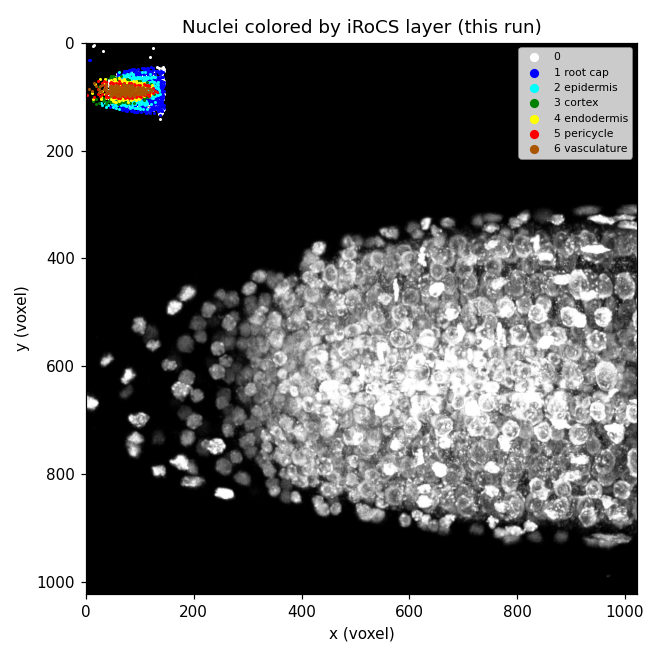

saved plot_zonation.png


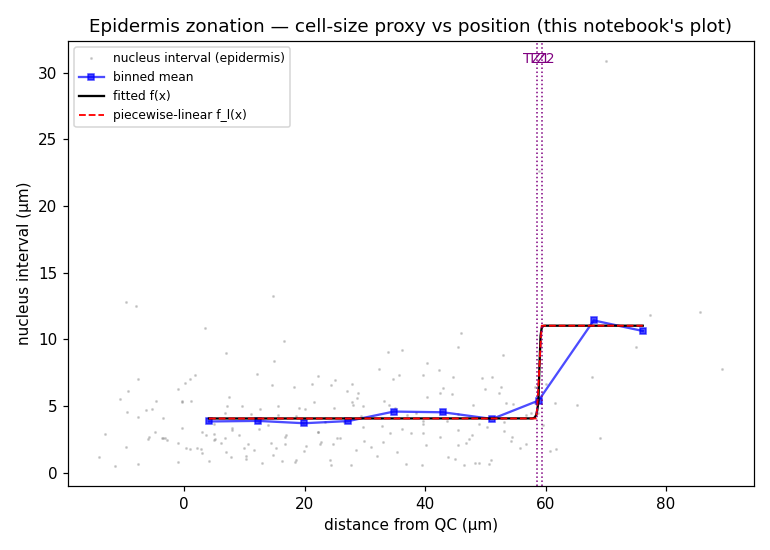

In [ ]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

colors = {1: "blue", 2: "cyan", 3: "green", 4: "yellow", 5: "red", 6: "#AA5500", 0: "white"}

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img.max(axis=0), cmap="gray")
for lab in sorted(set(label.tolist())):
    m = label == lab
    ax.scatter(pos[m, 2], pos[m, 1], s=1, c=colors.get(lab, "white"),
               label=f"{lab} {names.get(lab, '')}")
ax.set_title("Nuclei colored by iRoCS layer (this run)")
ax.legend(markerscale=5, fontsize=7, loc="upper right")
ax.set_xlabel("x (voxel)"); ax.set_ylabel("y (voxel)")
plt.tight_layout()
plt.savefig("/content/data/plot_layers.png", dpi=110)
plt.close()
print("saved plot_layers.png")

from IPython.display import display, Image
display(Image("/content/data/plot_layers.png"))

lab = 2
ft = fits[lab]
p = ft["p"]
xs = np.linspace(ft["bx"].min(), ft["bx"].max(), 400)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ft["xm"], ft["y"], ".", ms=2, alpha=0.3, color="gray", label="nucleus interval (epidermis)")
ax.plot(ft["bx"], ft["by"], "s-", ms=4, color="blue", alpha=0.7, label="binned mean")
ax.plot(xs, zone_model(xs, p), "-", color="black", lw=1.5, label="fitted f(x)")
ax.plot(xs, np.piecewise(xs, [xs < ft["c1"], (xs >= ft["c1"]) & (xs <= ft["c2"]), xs > ft["c2"]],
                         [p[2], lambda x: p[3] + ft["a"] * (x - p[0]), p[5]]),
        "--", color="red", lw=1.2, label="piecewise-linear f_l(x)")
for xb, nm in [(ft["c1"], "TZ1"), (ft["c2"], "TZ2")]:
    ax.axvline(xb, color="purple", ls=":", lw=1)
    ax.text(xb, ax.get_ylim()[1] * 0.95, nm, color="purple", fontsize=9, ha="center")
ax.set_xlabel("distance from QC (μm)"); ax.set_ylabel("nucleus interval (μm)")
ax.set_title("Epidermis zonation — cell-size proxy vs position (this notebook's plot)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("/content/data/plot_zonation.png", dpi=110)
plt.close()
print("saved plot_zonation.png")

from IPython.display import display, Image
display(Image("/content/data/plot_zonation.png"))

## 16. Results summary

Quantitative summary of this run. The per-nucleus table is exported as `nuclei_atlas.csv` (available in the Colab file panel under `/content/data/`).

この_runの定量結果。核ごとのテーブルは`nuclei_atlas.csv`としてエクスポートされます。

In [ ]:
import pandas as pd
summary = []
for lab in sorted(set(label.tolist())):
    m = label == lab
    summary.append({
        "layer": lab,
        "layer_name": names.get(lab, "background"),
        "n_nuclei": int(m.sum()),
        "qc_dist_median_um": round(float(np.median(qcd[m])), 1),
        "radius_median_um": round(float(np.median(radius[m])), 2),
    })
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
print()
for lab in [2, 3]:
    ft = fits[lab]
    if ft["sensible"]:
        print(f"{names[lab]}: MZ < {ft['c1']:.1f} um | EZ {ft['c1']:.1f}-{ft['c2']:.1f} um | "
              f"DZ > {ft['c2']:.1f} um (fit cost {ft['cost']:.2f})")
    else:
        print(f"{names[lab]}: no clear zonation — automatic nuclei proxy too noisy "
              f"(fit cost {ft['cost']:.2f}); the paper used expert-corrected cell-length data")
print()
print("Files in /content/data:")
for f in sorted(os.listdir("/content/data")):
    print("  ", f)

 layer  layer_name  n_nuclei  qc_dist_median_um  radius_median_um
     0  background       509               36.7               2.0
     1    root cap       471                7.6               2.0
     2   epidermis       243               25.9               2.0
     3      cortex        93               59.1               2.0
     4  endodermis       148               48.0               2.0
     5   pericycle       123               43.1               2.0
     6 vasculature       170               50.4               2.0

epidermis: MZ < 58.5 um | EZ 58.5-59.4 um | DZ > 59.4 um (fit cost 0.52)
cortex: no clear zonation — automatic nuclei proxy too noisy (fit cost 152.71); the paper used expert-corrected cell-length data

Files in /content/data:
   epidermisLabelling_svmModel.h5
   features.h5
   layerAssignment_svmModel.h5
   nuclei_atlas.csv
   nucleusDetector_svmModel.h5
   plot_layers.png
   plot_zonation.png
   preview_dapi.png
   rootTip_annotated.h5
   rootTip_short.h5


## 17. Interpretation, differences from the paper, and validation record

**What was reproduced.** The authors' iRoCS nuclei-analysis pipeline ran end-to-end on the authors' sample DAPI stack: 1757 nucleus candidates were detected, the epidermis was labelled, the iRoCS coordinate system was attached (QC estimated from the data), and every nucleus was assigned to a root layer. The downstream zonation analysis (Supplemental Method) was then applied: the cell-size proxy (nucleus interval within a layer/angular sector) increases with distance from the QC, and the 6-parameter model recovers a meristematic zone (MZ), an elongation zone (EZ), and a differentiation zone (DZ). For the epidermis the fit is clean (MZ ≲ 58 μm on this sample); the cortex proxy is noisier, consistent with the paper's own observation that automatic nuclei-based measurements are less reliable than expert-corrected cell-length data.

**Differences from the paper.** (1) One sample root, not the n=16/19 atlas. (2) DAPI only — the cell-wall segmentation path and the cell-volume analysis are not exercisable. (3) QC estimated from data, not manually indicated. (4) Cell-size proxy uses consecutive nuclei within a layer/angular sector, not true cell files (GUI-only). (5) Zone model fitted with scipy, not MATLAB. (6) Automatic, not expert-corrected, layer assignment. These are documented adaptations; the scientific operations (detection, coordinate system, layer assignment, zonation model) are the authors' own.

**Validation record.** This notebook was executed top-to-bottom on a Colab CPU runtime (see `notes/STATE.md` and `deliverables/report.md` for the session identity, timings, and archived outputs). The saved cell outputs are the actual results of that run. A one-example run is a partial demonstration, not a verification of the paper's dataset-level accuracy.

**References.** Blein et al., bioRxiv 353987 (2018), DOI 10.1101/353987; Schmidt et al. (2014) iRoCS Toolbox; iRoCS site http://lmb.informatik.uni-freiburg.de/lmbsoft/iRoCS; code https://github.com/lmb-freiburg/iRoCS-Toolbox @ 50b8510331e6b3fed973a91adf340333447f9de1 (GPL-3.0).